In [ ]:


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:

# Load the dataset
df = pd.read_csv("../data/bank.csv", sep=';')


In [7]:
def show_basic_info(df):
    print("\n--- BASIC INFO ---")
    print(df.info())

    print("\n--- DATA SHAPE ---")
    print("Rows:", df.shape[0], "Columns:", df.shape[1])

show_basic_info(df)



--- BASIC INFO ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   age        45211 non-null  int64 
 1   job        45211 non-null  object
 2   marital    45211 non-null  object
 3   education  45211 non-null  object
 4   default    45211 non-null  object
 5   balance    45211 non-null  int64 
 6   housing    45211 non-null  object
 7   loan       45211 non-null  object
 8   contact    45211 non-null  object
 9   day        45211 non-null  int64 
 10  month      45211 non-null  object
 11  duration   45211 non-null  int64 
 12  campaign   45211 non-null  int64 
 13  pdays      45211 non-null  int64 
 14  previous   45211 non-null  int64 
 15  poutcome   45211 non-null  object
 16  y          45211 non-null  object
dtypes: int64(7), object(10)
memory usage: 5.9+ MB
None

--- DATA SHAPE ---
Rows: 45211 Columns: 17


In [8]:
def show_statistics(df):
    print("\n--- STATISTICS ---")
    display(df.describe())

show_statistics(df)



--- STATISTICS ---


,age,balance,day,duration,campaign,pdays,previous
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000


In [9]:
def check_missing_and_unknown(df):
    print("\n--- MISSING VALUES ---")
    missing = df.isnull().sum()
    print(missing[missing > 0] if missing.any() else "No missing values.")

    print("\n--- UNKNOWN VALUES ---")
    unknown = (df == "unknown").sum()
    print(unknown[unknown > 0])

check_missing_and_unknown(df)



--- MISSING VALUES ---
No missing values.

--- UNKNOWN VALUES ---
job            288
education     1857
contact      13020
poutcome     36959
dtype: int64



--- TARGET DISTRIBUTION ---
y
no     39922
yes     5289
Name: count, dtype: int64


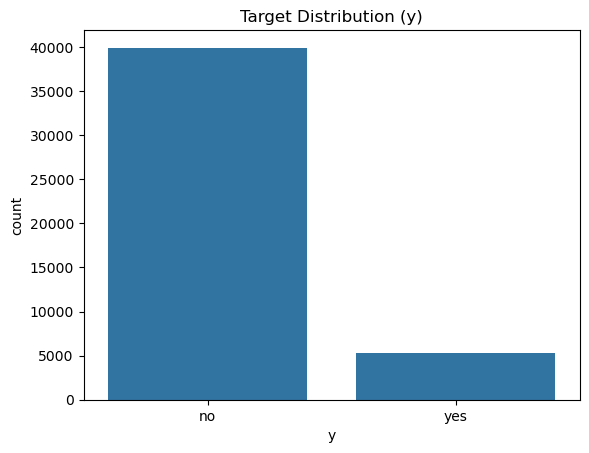

In [10]:
def plot_target_distribution(df):
    print("\n--- TARGET DISTRIBUTION ---")
    print(df['y'].value_counts())

    sns.countplot(x='y', data=df)
    plt.title("Target Distribution (y)")
    plt.show()

plot_target_distribution(df)


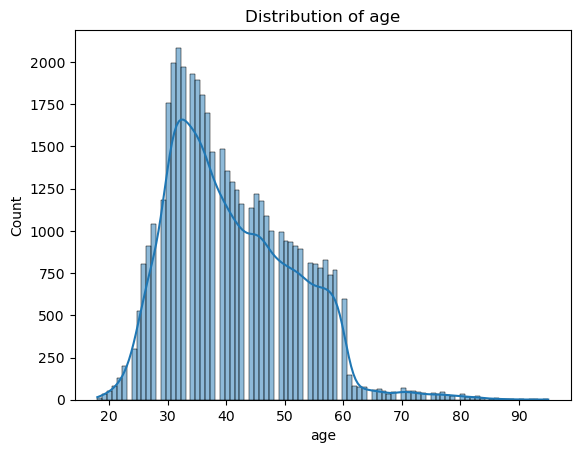

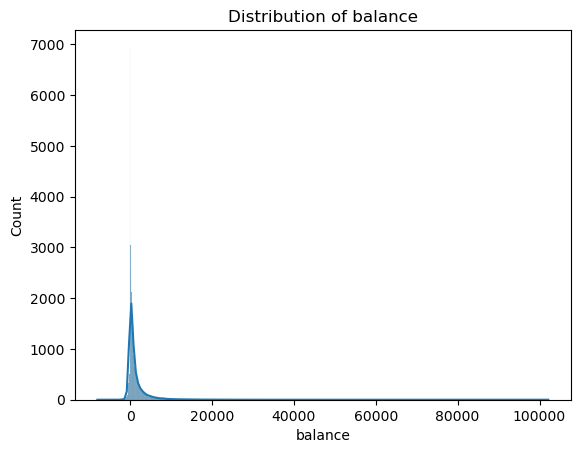

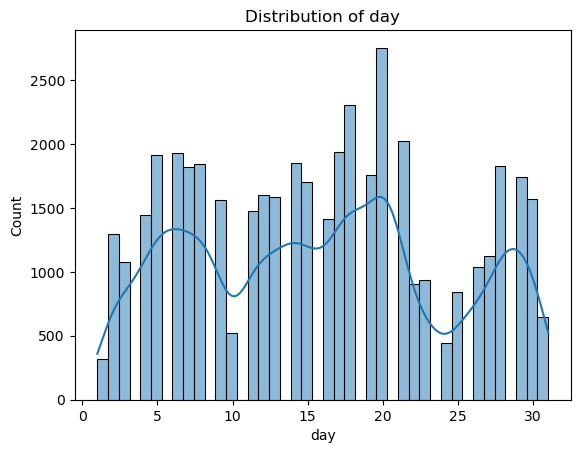

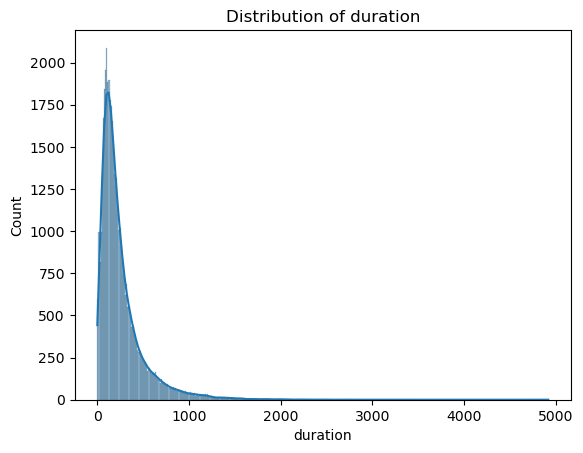

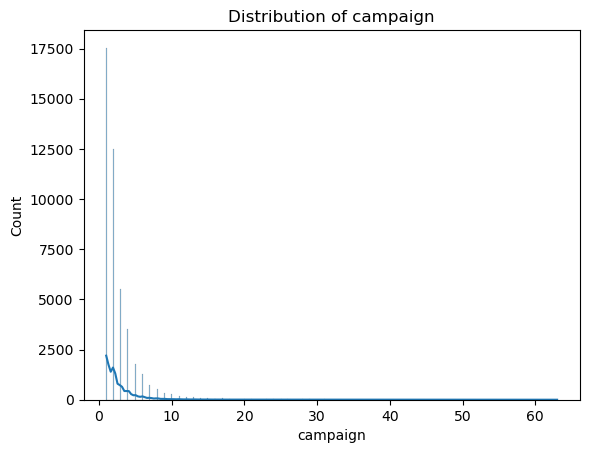

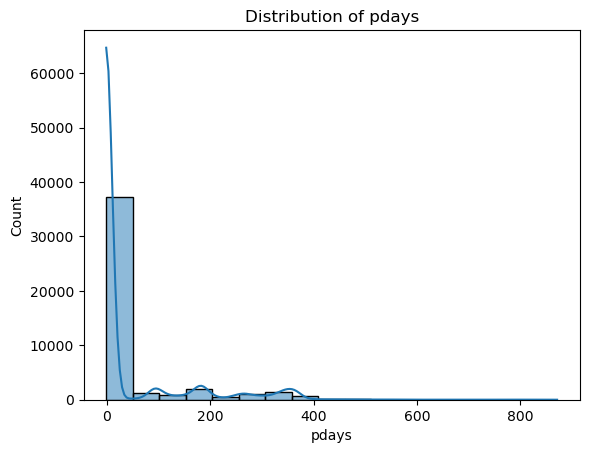

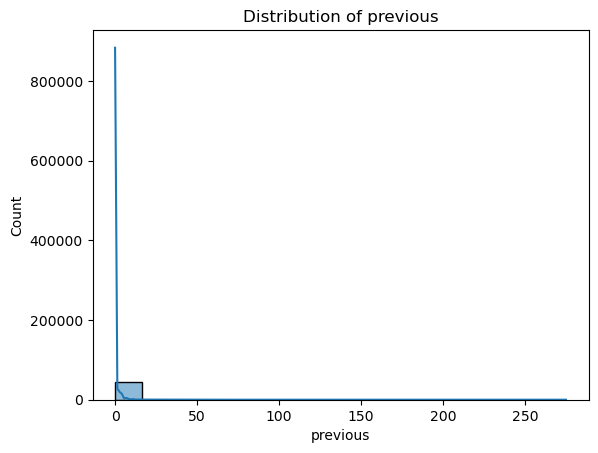

In [13]:
def plot_numerical_distributions(df):
    num_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        plt.figure()
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

plot_numerical_distributions(df)


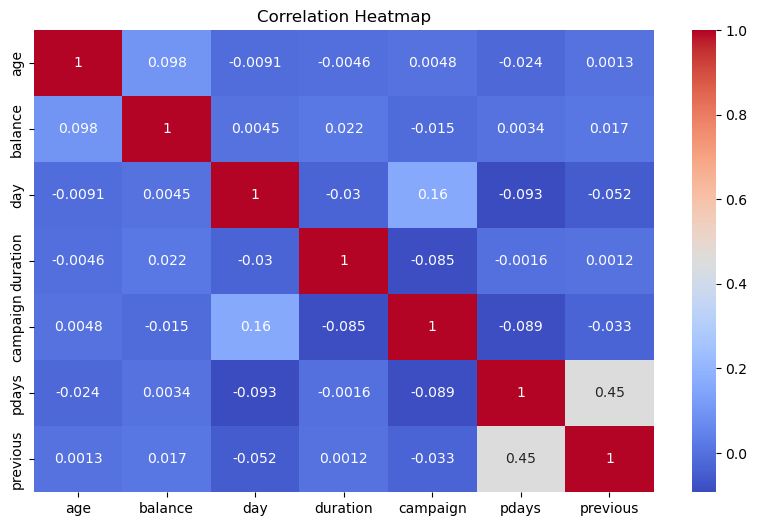

In [14]:
def plot_correlation_heatmap(df):
    plt.figure(figsize=(10, 6))
    corr = df.corr(numeric_only=True)
    sns.heatmap(corr, annot=True, cmap="coolwarm")
    plt.title("Correlation Heatmap")
    plt.show()

plot_correlation_heatmap(df)


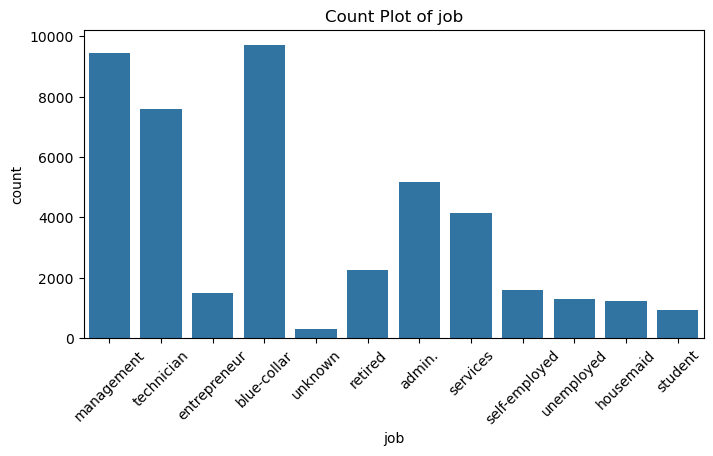

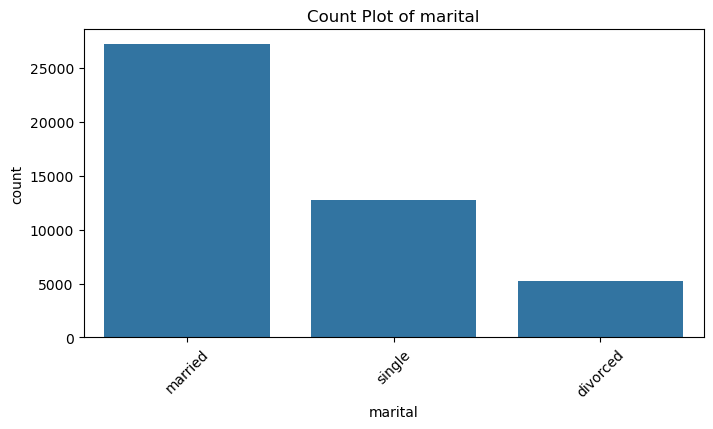

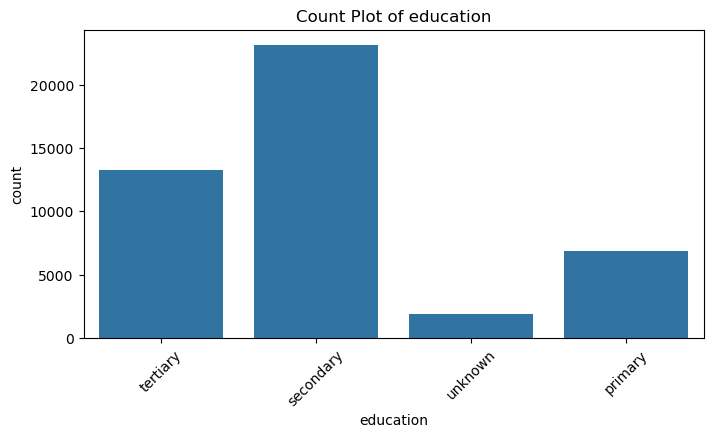

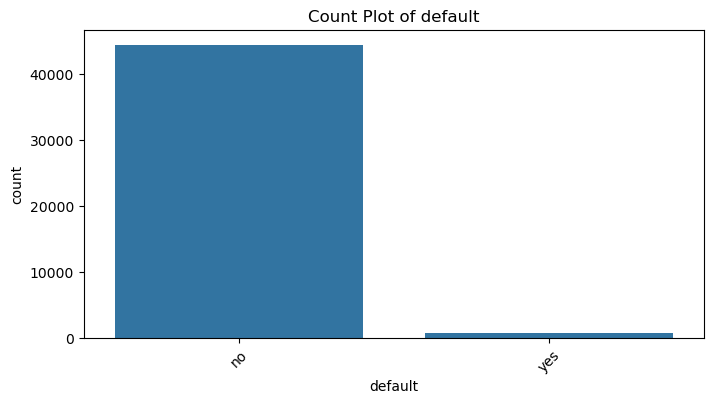

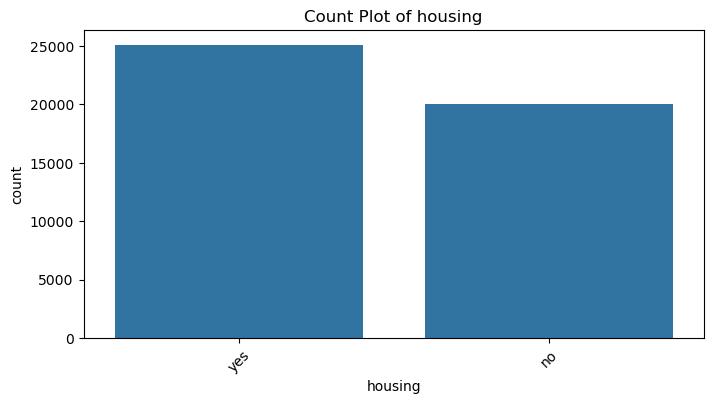

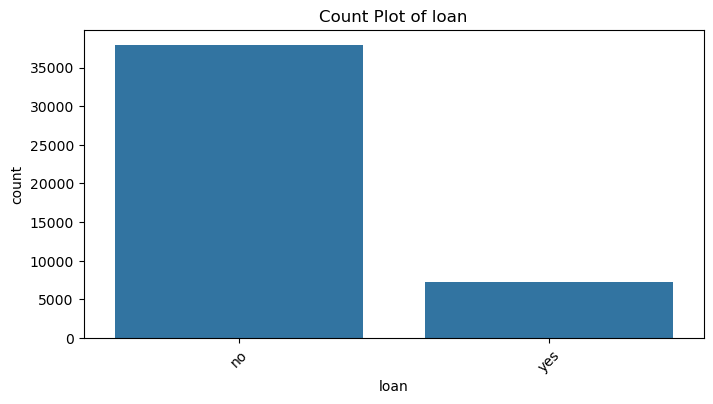

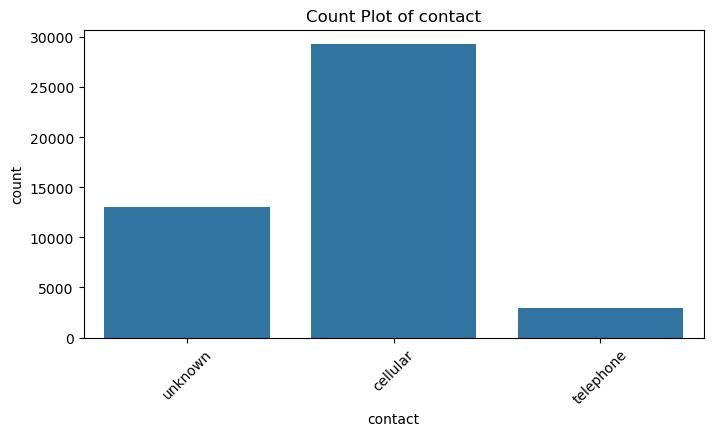

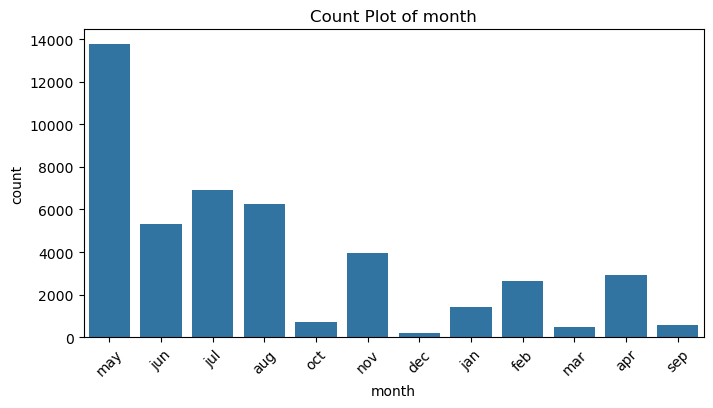

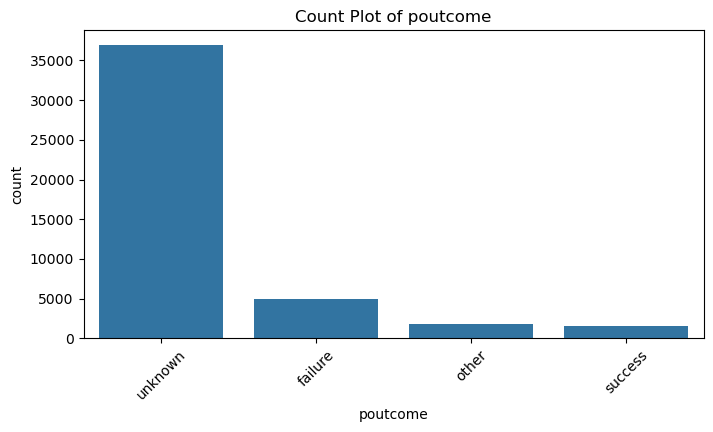

In [15]:
def plot_categorical_counts(df):
    cat_cols = df.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if col != 'y':
            plt.figure(figsize=(8, 4))
            sns.countplot(x=col, data=df)
            plt.xticks(rotation=45)
            plt.title(f"Count Plot of {col}")
            plt.show()

plot_categorical_counts(df)
